In [29]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "bread_basket.csv" in files:
        print(os.path.join(root, "bread_basket.csv"))

/content/drive/MyDrive/Untitled folder/bread_basket.csv


In this section , the required libararies are importrd and Google Drive is mounted to access the dataset file . The Bread Basket datasrt is located inside Google Drive and loaded into a pandas DataFrame.Intial checks are performed to confirm the file path and verify that the data loads cofirm the file path and verfiy that the data loads correctly.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Drive is mounted so that Colab can access the files stored in MyDrive. This will allows to read datasets directly from cloud storage.

In [31]:
import os
print(os.listdir("/content/drive/MyDrive/Untitled folder"))


['bread_basket.csv']


The os.listdir() function is used to verify that the dataset exists inside the specified folder before loading it.

In [32]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Untitled folder/bread_basket.csv")
df.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


The dataset is loaded using pandas.read_csv(), and the first few rows are displayed to confirm successful loading.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


The df.info() function is used to inspect the structure of the dataset.  
The dataset contains 20,507 records and 6 columns.  
The transaction column is numeric, while the remaining columns are categorical (object type).  
There are no missing values since all columns contain 20,507 non-null entries.

In [34]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


The describe() function provides a statistical overview of the dataset.  
For categorical columns, it shows information such as unique values and most frequent items.  
This helps understand item distribution and overall dataset characteristics before applying association rule mining.

In [35]:
df.isnull().sum()


,0
transaction,0
item,0
date_time,0
time,0
period_day,0
weekday_weekend,0


The isnull().sum() function is used to check for missing values in each coulmn of the dataset.The output shows that all columns contain zero missing values, meaing the dataset is complete and ready for analyis without cleaning.

In [36]:
df['transaction'].nunique()

9465

counting how many unique transactions (baskets) exist.
So there are 9,465 different customer transactions in the dataset.

In [37]:
top_items = df['item'].value_counts().head(10)
top_items

,count
item,
Coffee,5471
Bread,3325
Tea,1435
Cake,1025
Pastry,856
Sandwich,771
Medialuna,616
Hot chocolate,590
Cookies,540


### Top 10 Most Purchased Items

The value_counts() function is used to identify the most frequently purchased items in the dataset.  
The results show that Coffee is the most popular item, followed by Bread, Tea, and Cake.  
This information helps understand customer purchasing behavior and provides insight into which products are most important for association rule mining.

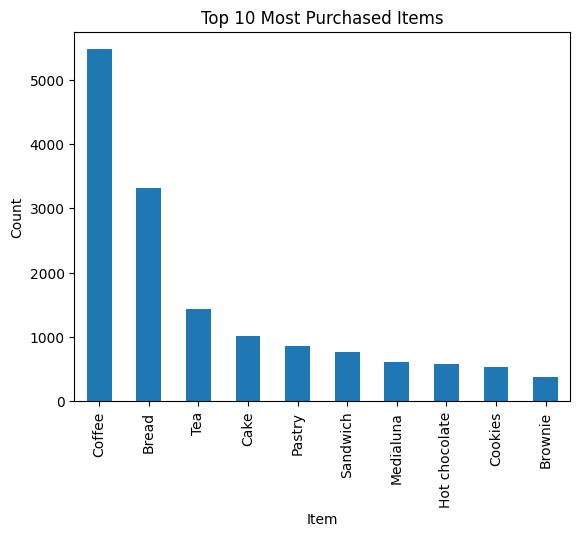

In [38]:
import matplotlib.pyplot as plt

top_items.plot(kind='bar')
plt.title("Top 10 Most Purchased Items")
plt.xlabel("Item")
plt.ylabel("Count")
plt.show()

This bar chart visualizes the top 10 most frequently purchased items in the bakery dataset.Coffee and bread appear as the most poular items, followed by Tea, Cake and Pastry.The visualization helps identify dominant products and provides insight into customer purchasing patterns ,which is useful for later association rule minning.

In [39]:
!pip install mlxtend

The mlxtend library is installed because it provides the FP-Growth algorithm and association rule functions used in this assignment.

In [40]:
transactions = df.groupby('transaction')['item'].apply(list).tolist()
transactions[:5]

[['Bread'],
 ['Scandinavian', 'Scandinavian'],
 ['Hot chocolate', 'Jam', 'Cookies'],
 ['Muffin'],
 ['Coffee', 'Pastry', 'Bread']]

This dataset is grouped by transction ID so that each transtion becomes a list of purchased items.This transformation converts the data into basket format, which is required for the  FP grwoth algorthim.Each list represents one customer purchase containg one or more items.

In [41]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)
basket.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



To apply FP-Growth, the transactions are transformed into a one-hot encoded basket matrix using TransactionEncoder.  
Each row represents a transaction, and each column represents an item.  
A value of True means the item was included in that transaction, and False means it was not.  
This basket format is required for frequent itemset mining.

In [42]:
import warnings
warnings.filterwarnings("ignore")
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.327205,(Bread)
1,0.029054,(Scandinavian)
2,0.058320,(Hot chocolate)
3,0.054411,(Cookies)
4,0.038457,(Muffin)


The FP-Growth algorithm is applied to the basket dataset to discover frequent itemsets based on a minimum support threshold of 0.02.  
The support value represents the proportion of transactions containing each itemset.  
For example, Bread appears in approximately 32.7% of all transactions, making it one of the most frequent items.

In [43]:
import warnings
warnings.filterwarnings("ignore")
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542
1,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707
2,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
3,(Pastry),(Bread),0.086107,0.327205,0.029160,0.338650,1.034977,1.0,0.000985,1.017305,0.036980,0.075908,0.017011,0.213884
4,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387




Association rules are generated from the frequent itemsets using confidence as the evaluation metric.  
Each rule shows relationships between items frequently purchased together.  
For example, the rule (Hot chocolate → Coffee) suggests that customers who buy hot chocolate are likely to also purchase coffee.  
Support indicates how common the rule is, while confidence shows the probability of the consequent given the antecedent.

In [44]:
# Clean report table (easy to read)
report = rules[['antecedents','consequents','support','confidence','lift']].copy()

# Convert frozensets to readable strings
report['antecedents'] = report['antecedents'].apply(lambda s: ', '.join(sorted(list(s))))
report['consequents'] = report['consequents'].apply(lambda s: ', '.join(sorted(list(s))))

# Sort so best rules appear first
report = report.sort_values(['lift','confidence','support'], ascending=False)

report.head(20)

,antecedents,consequents,support,confidence,lift
9,Toast,Coffee,0.023666,0.704403,1.472431
4,Medialuna,Coffee,0.035182,0.569231,1.189878
2,Pastry,Coffee,0.047544,0.552147,1.154168
6,Juice,Coffee,0.020602,0.534247,1.116750
8,Sandwich,Coffee,0.038246,0.532353,1.112792
7,Cake,Coffee,0.054728,0.526958,1.101515
1,Cookies,Coffee,0.028209,0.518447,1.083723
0,Hot chocolate,Coffee,0.029583,0.507246,1.060311
3,Pastry,Bread,0.029160,0.338650,1.034977
5,Tea,Coffee,0.049868,0.349630,0.730840


The generated association rules are organized into a clean report table containing antecedents, consequents, support, confidence, and lift values.  
The rules are sorted so that the strongest relationships appear first, making interpretation easier.

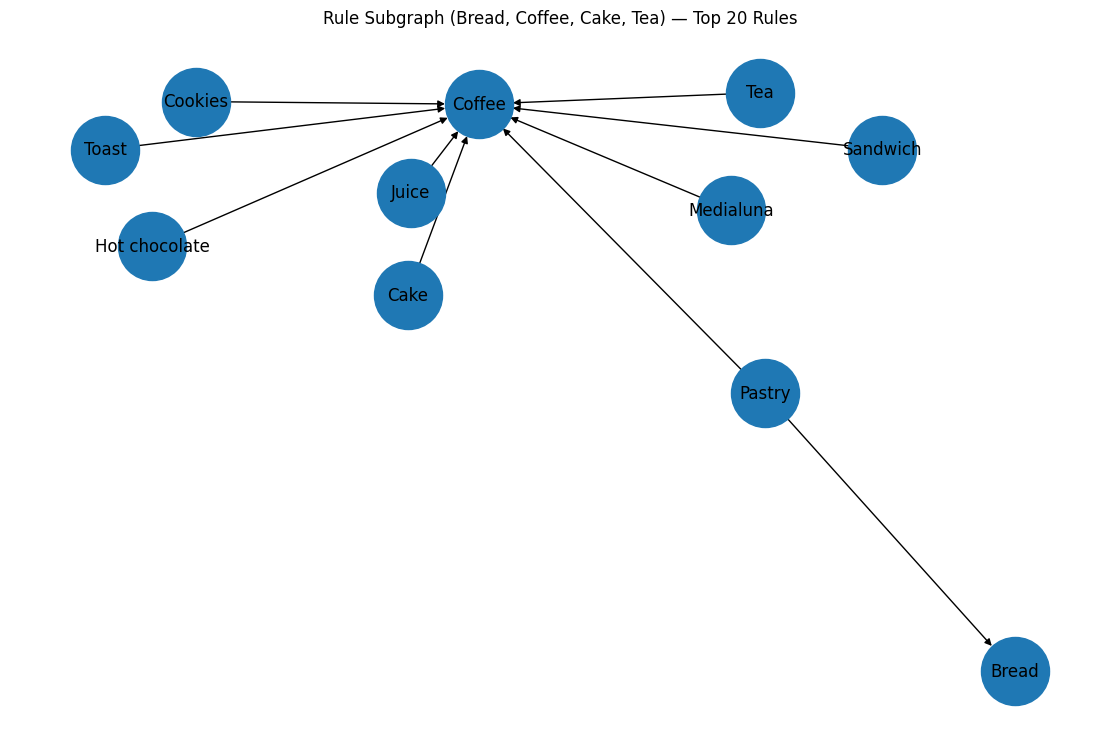

In [45]:
import warnings
warnings.filterwarnings("ignore")

import networkx as nx
import matplotlib.pyplot as plt

focus = {'Bread', 'Coffee', 'Cake', 'Tea'}

# Keep rules that involve at least one focus item
sub_rules = rules[
    rules['antecedents'].apply(lambda s: any(x in focus for x in s)) |
    rules['consequents'].apply(lambda s: any(x in focus for x in s))
].copy()

# Sort by strength and keep top N so graph shows enough connections
sub_rules = sub_rules.sort_values(['lift','confidence'], ascending=False).head(20)

# Build the graph
G = nx.DiGraph()
for _, r in sub_rules.iterrows():
    A = list(r['antecedents'])
    C = list(r['consequents'])
    for a in A:
        for c in C:
            G.add_edge(a, c, weight=float(r['lift']))

# Plot only the graph
plt.figure(figsize=(11,7))
pos = nx.spring_layout(G, seed=7, k=0.8)
nx.draw(G, pos, with_labels=True, node_size=2400, arrows=True)
plt.title("Rule Subgraph (Bread, Coffee, Cake, Tea) — Top 20 Rules")
plt.tight_layout()
plt.show()

This graph visualizes the strongest association rules that involve Bread, Coffee, Cake, and Tea.  
Nodes represent items and directed edges represent association rules between items.  
Only the top rules (highest lift/confidence) are shown to keep the visualization clear.

In [46]:
report.sort_values(["lift","confidence"], ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
9,Toast,Coffee,0.023666,0.704403,1.472431
4,Medialuna,Coffee,0.035182,0.569231,1.189878
2,Pastry,Coffee,0.047544,0.552147,1.154168
6,Juice,Coffee,0.020602,0.534247,1.116750
8,Sandwich,Coffee,0.038246,0.532353,1.112792
7,Cake,Coffee,0.054728,0.526958,1.101515
1,Cookies,Coffee,0.028209,0.518447,1.083723
0,Hot chocolate,Coffee,0.029583,0.507246,1.060311
3,Pastry,Bread,0.029160,0.338650,1.034977
5,Tea,Coffee,0.049868,0.349630,0.730840


This rule means that customers who purchase toast are very likely to also purchase coffee.  
The support value (0.0237) indicates that about 2.37% of all transactions contain both toast and coffee.  
The confidence value (0.704) shows that approximately 70% of customers who buy toast also buy coffee.  
The lift value (1.47) is greater than 1, indicating that this relationship is stronger than random chance.

From a business perspective, this suggests that toast and coffee are commonly purchased together, so placing them near each other or offering bundle promotions could help increase sales.